In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_excel("Flight_Fare.xlsx")

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [5]:
df.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
df.shape

(10683, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


In [8]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [9]:
df.dropna(inplace=True)

In [10]:
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month
df["Journey_Year"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.year
df.drop("Date_of_Journey", axis=1, inplace=True)

In [11]:
def convert_duration(x):
    x = x.replace("h", " ").replace("m", " ").split()
    if len(x) == 2:
        return int(x[0])*60 + int(x[1])
    else:
        return int(x[0])*60
    
df["Duration_Time"] = df["Duration"].apply(convert_duration)
df.drop("Duration",axis=1,inplace=True)

In [12]:
from sklearn.preprocessing import LabelEncoder

le_airline = LabelEncoder()
le_source = LabelEncoder()
le_destination = LabelEncoder()

df["Airline"] = le_airline.fit_transform(df["Airline"])
df["Source"] = le_source.fit_transform(df["Source"])
df["Destination"] = le_destination.fit_transform(df["Destination"])

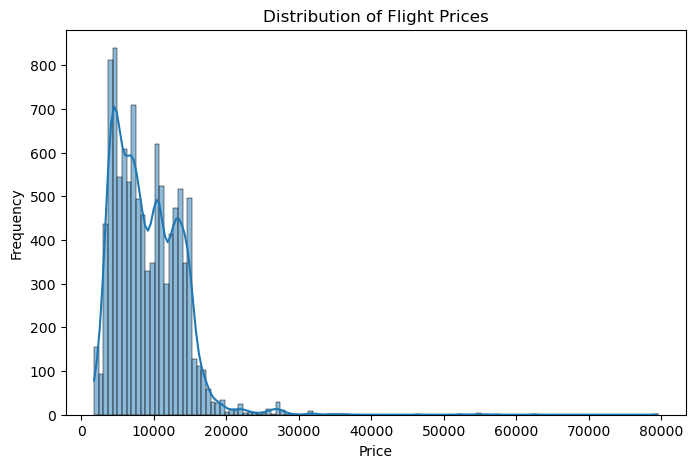

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

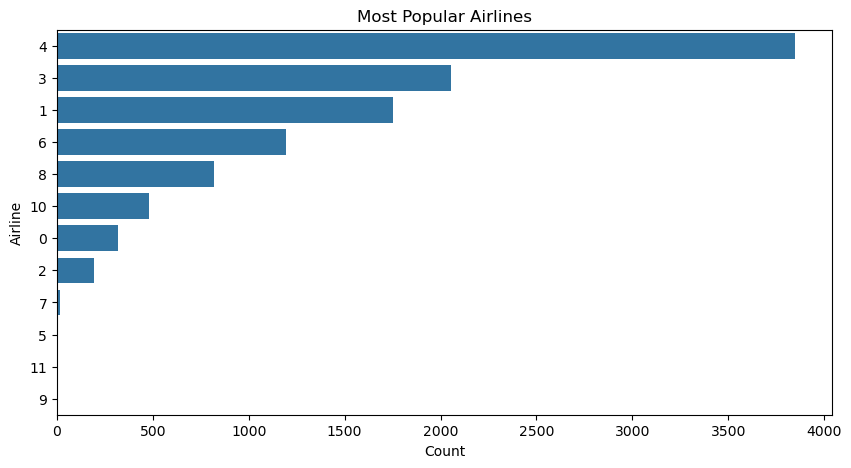

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Airline'], order=df['Airline'].value_counts().index)
plt.title('Most Popular Airlines')
plt.xlabel('Count')
plt.ylabel('Airline')
plt.show()

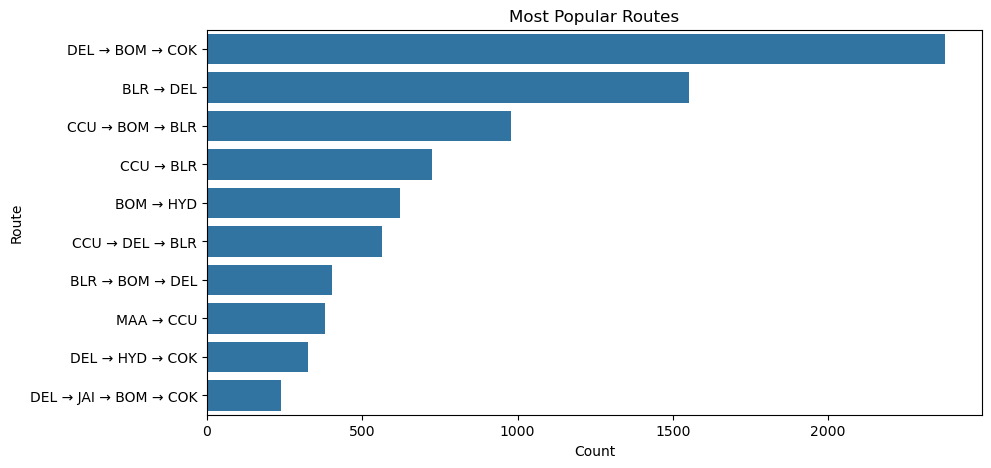

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Route'], order=df['Route'].value_counts().index[:10]) # Top 10 routes
plt.title('Most Popular Routes')
plt.xlabel('Count')
plt.ylabel('Route')
plt.show()

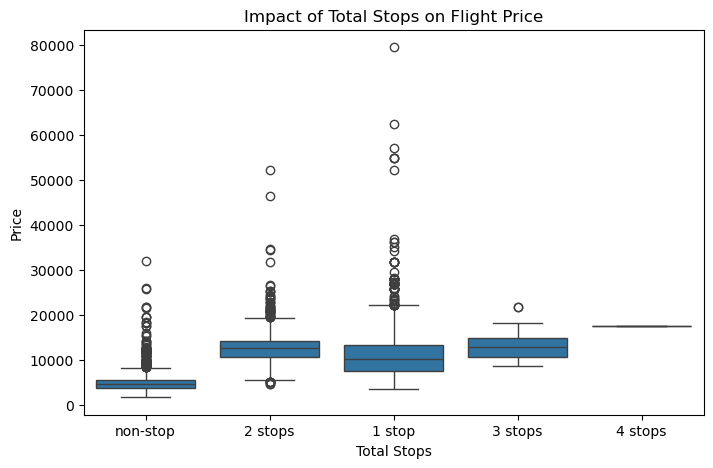

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Stops'], y=df['Price'])
plt.title('Impact of Total Stops on Flight Price')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.show()

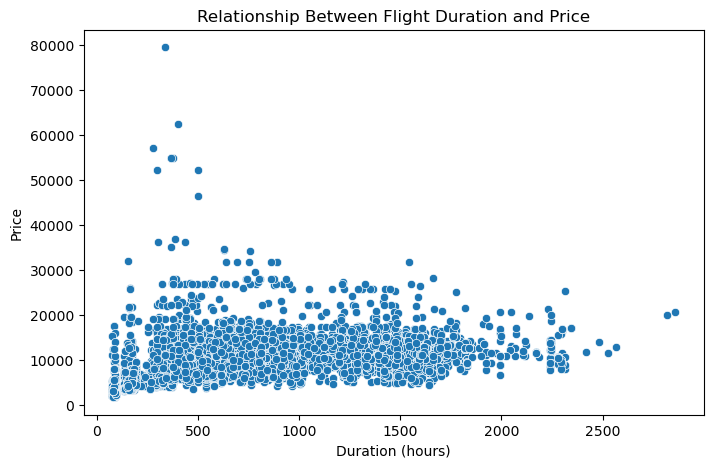

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Duration_Time'], y=df['Price'])
plt.title('Relationship Between Flight Duration and Price')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.show()

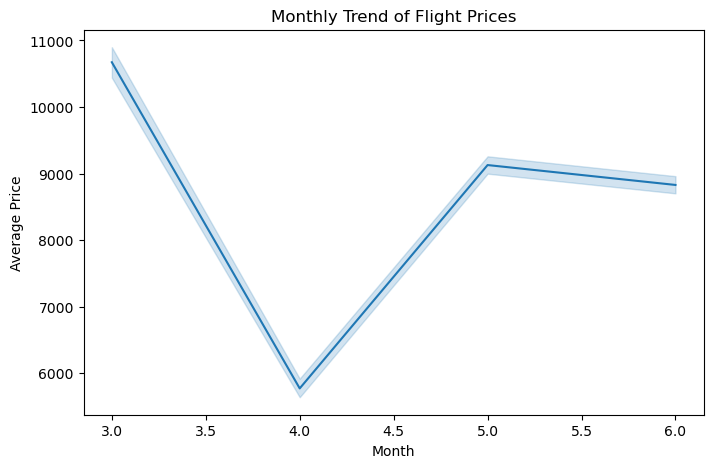

In [18]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df['Journey_Month'], y=df['Price'], estimator='mean')
plt.title('Monthly Trend of Flight Prices')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.show()

<Axes: >

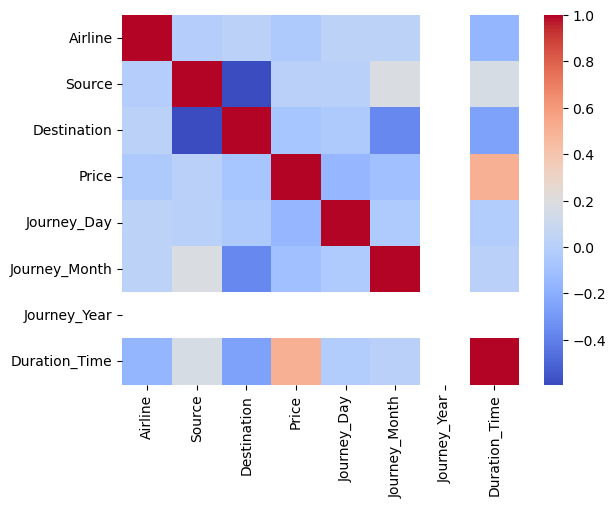

In [19]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

In [20]:
df["Total_Stops"] = df["Total_Stops"].replace({"non-stop": 0,"1 stop": 1,"2 stops": 2,"3 stops": 3,"4 stops": 4})

In [21]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])

df['Dep_Hour'] = df['Dep_Time'].dt.hour
df['Dep_Min']  = df['Dep_Time'].dt.minute

df['Arr_Hour'] = df['Arrival_Time'].dt.hour
df['Arr_Min']  = df['Arrival_Time'].dt.minute

df = df.drop(['Dep_Time', 'Arrival_Time'], axis=1)

In [22]:
num_cols = df.select_dtypes(include=['int64',"int32",'float64']).columns.tolist()
num_cols

['Airline',
 'Source',
 'Destination',
 'Price',
 'Journey_Day',
 'Journey_Month',
 'Journey_Year',
 'Duration_Time',
 'Dep_Hour',
 'Dep_Min',
 'Arr_Hour',
 'Arr_Min']

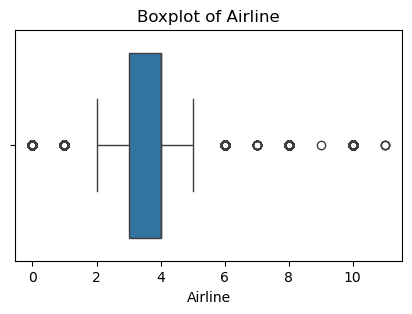

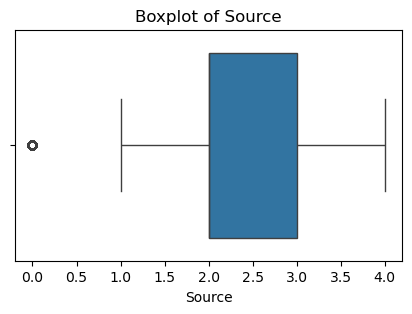

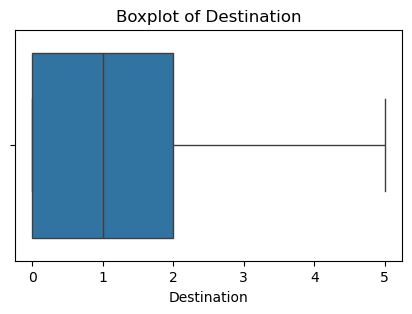

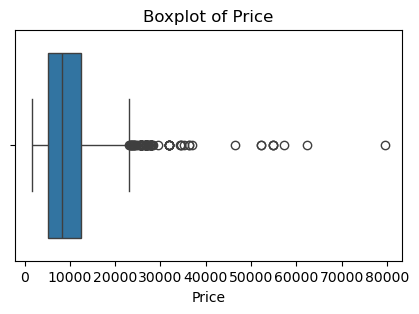

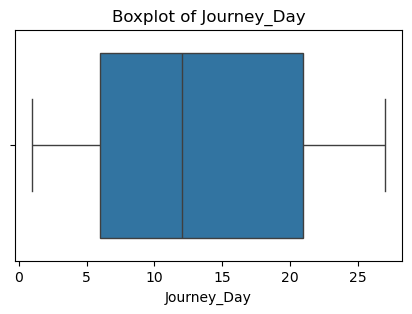

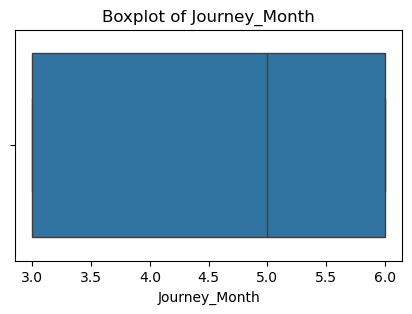

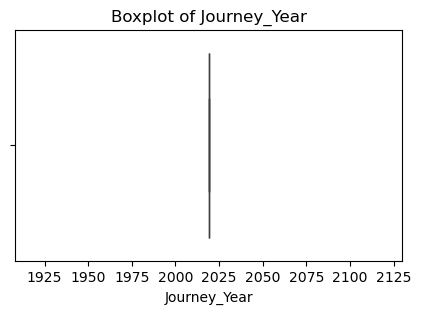

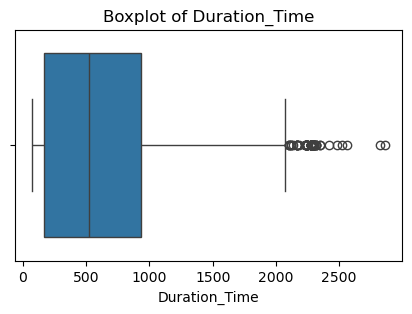

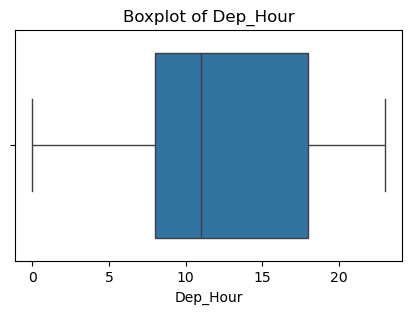

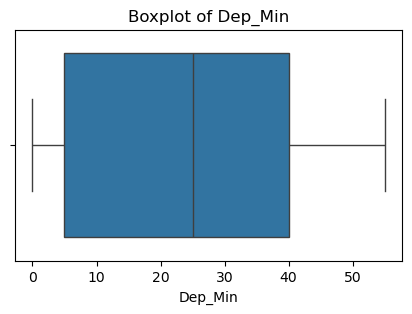

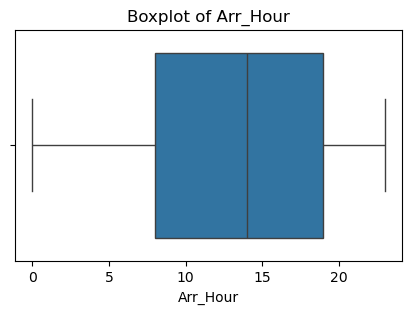

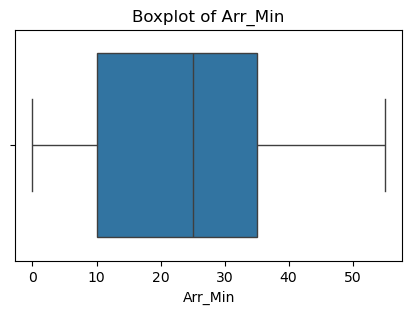

In [23]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [24]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_limit, upper_limit,np.where(df[col] < lower_limit, lower_limit, df[col]))

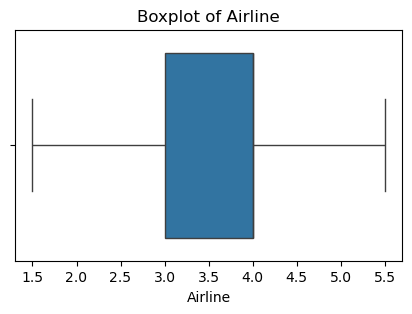

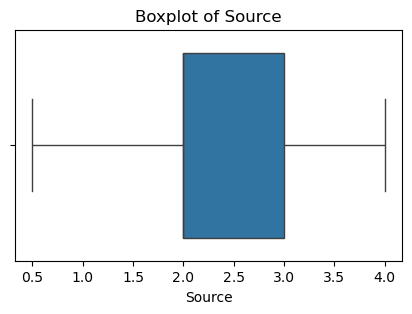

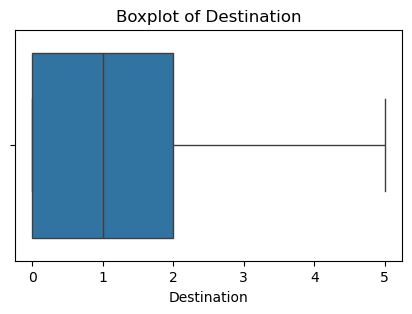

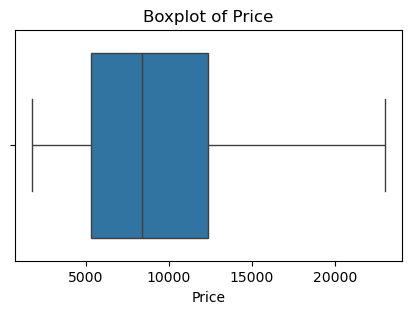

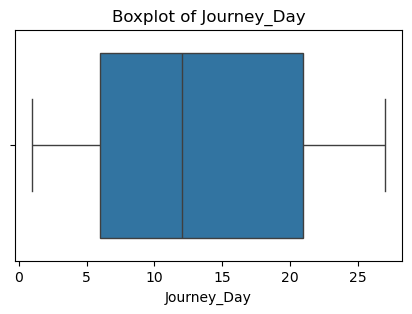

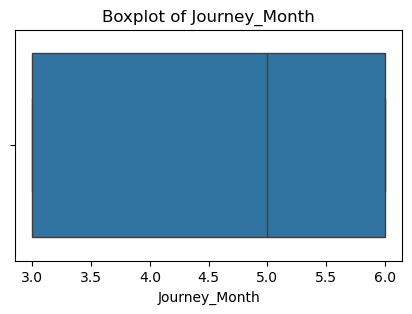

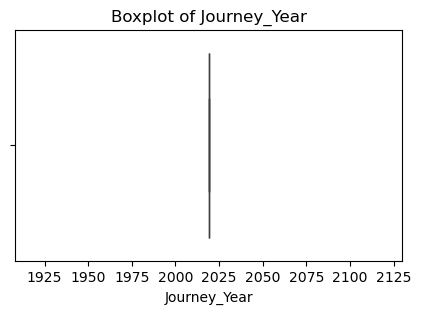

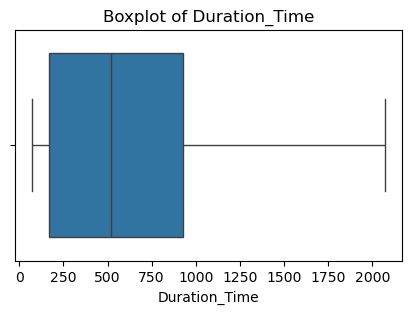

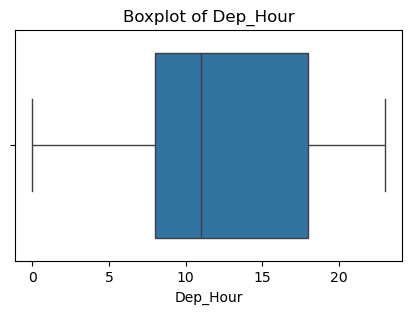

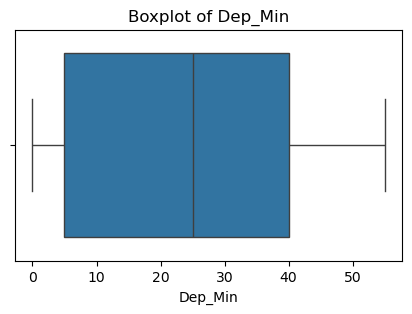

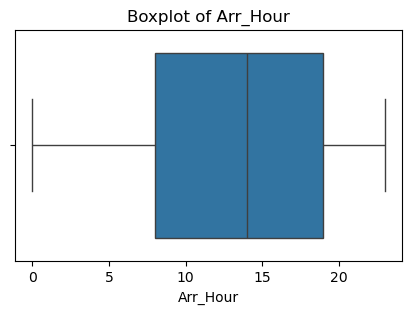

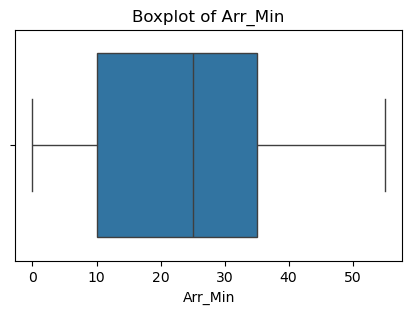

In [25]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [26]:
df.drop("Route",axis=1,inplace=True)

In [27]:
df.drop("Additional_Info",axis=1,inplace=True)

In [28]:
df.isna().sum()

Airline          0
Source           0
Destination      0
Total_Stops      0
Price            0
Journey_Day      0
Journey_Month    0
Journey_Year     0
Duration_Time    0
Dep_Hour         0
Dep_Min          0
Arr_Hour         0
Arr_Min          0
dtype: int64

In [29]:
df.head(2)

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Year,Duration_Time,Dep_Hour,Dep_Min,Arr_Hour,Arr_Min
0,3.0,0.5,5.0,0,3897.0,24.0,3.0,2019.0,170.0,22.0,20.0,1.0,10.0
1,1.5,3.0,0.0,2,7662.0,1.0,5.0,2019.0,445.0,5.0,50.0,13.0,15.0


In [30]:
x=df.drop("Price",axis=1)
y=df["Price"]

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [34]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [35]:
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, pred):
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae,rmse,r2

In [37]:
results = {"Linear Regression": evaluate(y_test,lr_pred),"Random Forest": evaluate(y_test,rf_pred)}
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2 Score"]).T
results_df

,MAE,RMSE,R2 Score
Linear Regression,2313.980822,3049.248715,0.501572
Random Forest,1162.905389,1810.959386,0.824194


In [38]:
print(df["Total_Stops"].dtype)

object


In [39]:
print(df["Total_Stops"].unique())

[0 2 1 3 4]


In [40]:
print(df["Total_Stops"].dtype)

object


In [41]:
df["Total_Stops"] = df["Total_Stops"].astype(int)

In [42]:
print(df["Total_Stops"].dtype)

int64


In [43]:
x = df.drop("Price", axis=1)   
y = df["Price"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [44]:
print(x_train.select_dtypes(include='object').columns)

Index([], dtype='str')


In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=6,
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

In [46]:
xgb_pred = xgb.predict(x_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1202.5267970897798
MSE : 2931288.099961318
RMSE : 1712.10049353457
R2 Score : 0.8428642877178045


In [48]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_pred
})

print(results.head(10))

       Actual     Predicted
6075  16655.0  17290.189453
3544   4959.0   6456.443359
9291   9187.0   9155.423828
5032   3858.0   4199.738281
2483  12898.0  13333.687500
9894  10529.0  10159.331055
346   16079.0  13371.721680
6365   7229.0   5963.851074
7624  10844.0  12876.394531
3393  16289.0  13560.412109


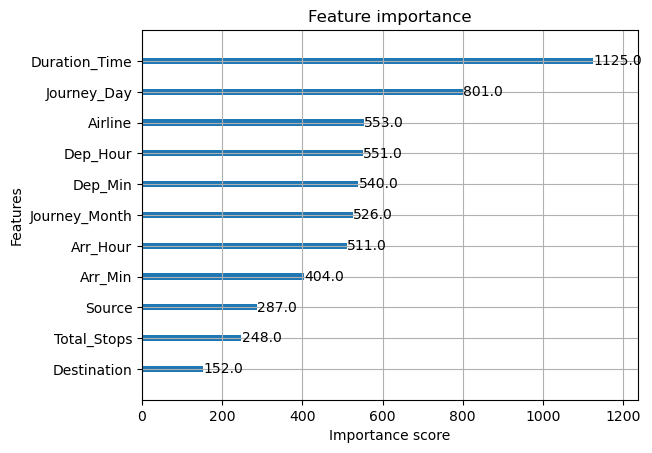

In [49]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb)
plt.show()

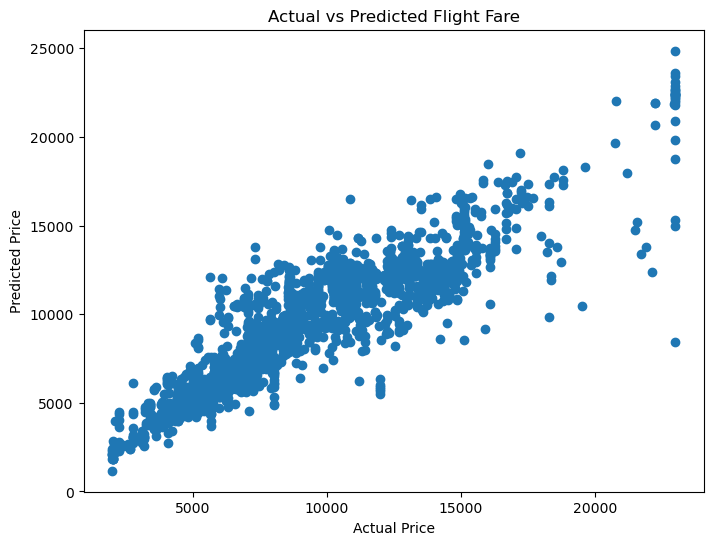

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Fare")
plt.show()

In [51]:
import pickle

pickle.dump(xgb, open("flight_fare_model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully


In [52]:
pickle.dump(le_airline, open("airline_encoder.pkl","wb"))
pickle.dump(le_source, open("source_encoder.pkl","wb"))
pickle.dump(le_destination, open("destination_encoder.pkl","wb"))